In [29]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

In [30]:
# Read the training and test datasets
train_data = pd.read_csv('train_df.csv')
test_data = pd.read_csv('test_df.csv')

## Show sample data and data shapes

In [31]:
train_data

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0
...,...,...,...,...,...,...,...,...
4995,77,Female,Heart Disease,3,13,1,Rehabilitation Facility,0
4996,43,Female,Heart Disease,3,9,3,Home Health Care,0
4997,58,Female,Kidney Disease,9,11,3,Home Health Care,0
4998,53,Male,COPD,6,1,0,Rehabilitation Facility,0


In [5]:
print("Shape of train_data:", train_data.shape)

Shape of train_data: (5000, 8)


In [32]:
train_data[train_data['readmitted']==1]

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
19,66,Female,COPD,3,7,2,Home Health Care,1
20,76,Male,Heart Disease,6,14,1,Skilled Nursing Facility,1
22,77,Male,COPD,7,5,1,Home Health Care,1
45,61,Male,COPD,0,5,0,Rehabilitation Facility,1
66,79,Male,COPD,2,9,0,Home,1
...,...,...,...,...,...,...,...,...
4971,25,Male,Kidney Disease,9,8,1,Skilled Nursing Facility,1
4974,68,Male,COPD,3,14,0,Home Health Care,1
4975,84,Male,Diabetes,8,7,4,Home,1
4980,26,Female,Heart Disease,1,5,3,Home,1


## test data and data shapes

In [ ]:
test_data.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to
0,52,Male,Heart Disease,3,9,3,Home
1,47,Female,Diabetes,2,4,0,Skilled Nursing Facility
2,72,Female,Heart Disease,7,12,4,Home
3,18,Female,COPD,5,14,3,Home
4,32,Male,Heart Disease,9,2,4,Rehabilitation Facility


In [7]:
print("Shape of test_data:", test_data.shape)

Shape of test_data: (2000, 7)


# Data Visualization

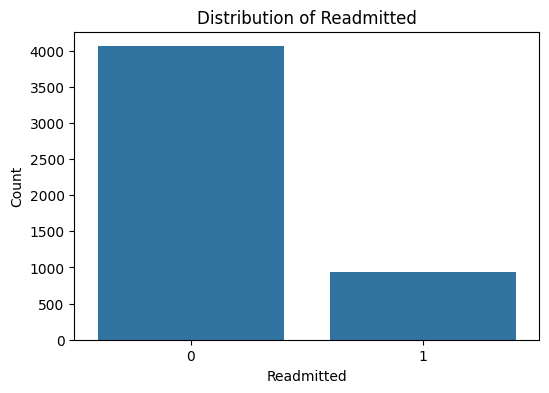

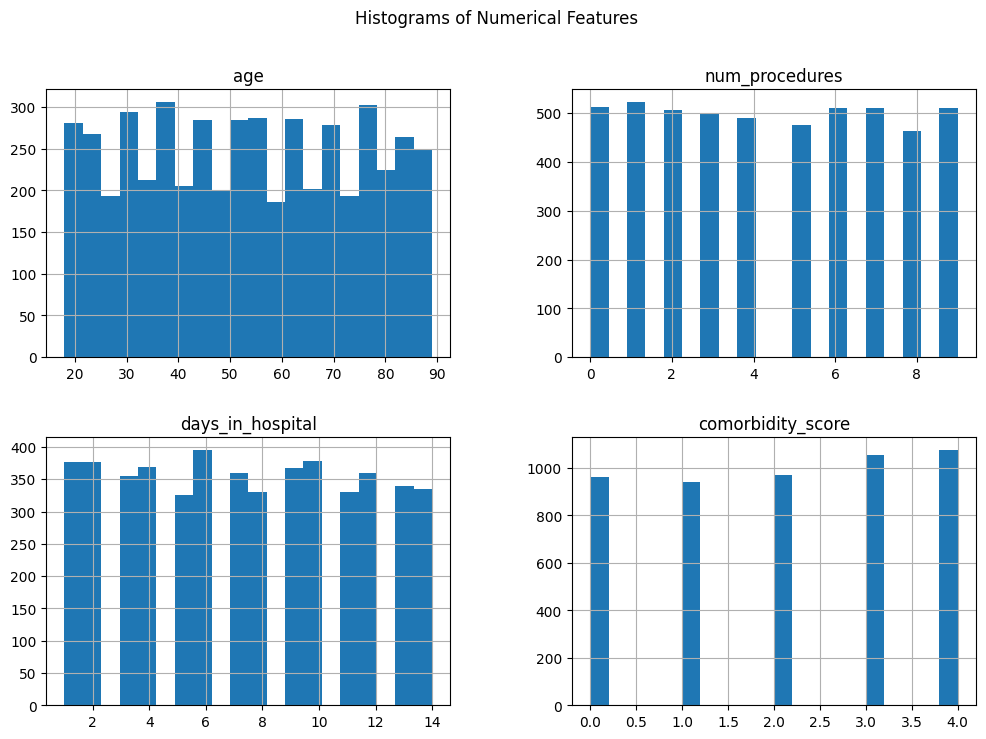

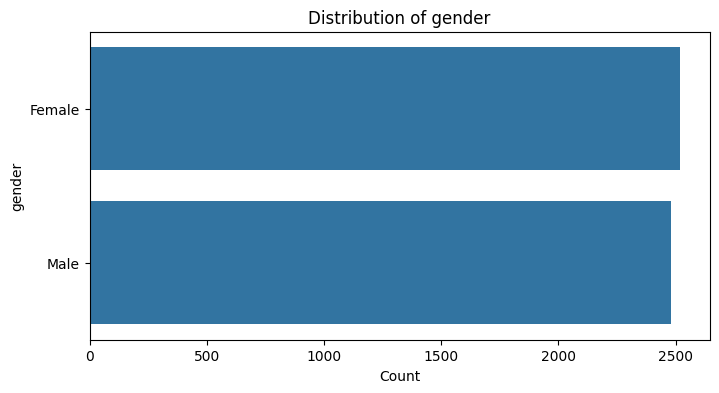

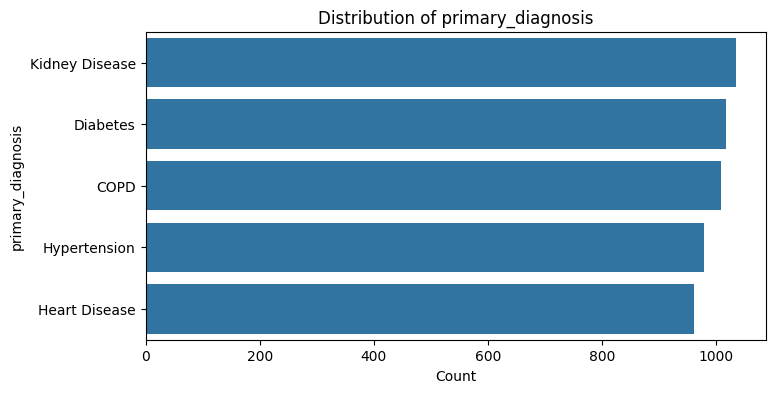

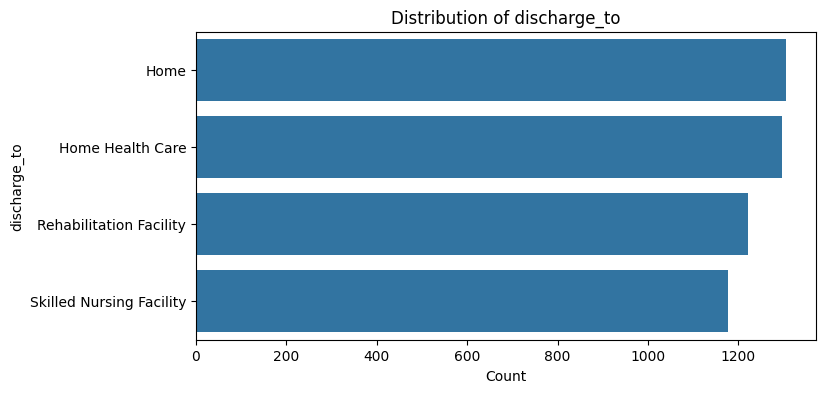

In [17]:
# Plot the distribution of the target variable 'readmitted'
plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted', data=train_data)
plt.title('Distribution of Readmitted')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()

# Plot the distribution of numerical features
num_features = ['age', 'num_procedures', 'days_in_hospital', 'comorbidity_score']
train_data[num_features].hist(bins=20, figsize=(12, 8))
plt.suptitle('Histograms of Numerical Features')
plt.show()

# Plot the count of categorical features
cat_features = ['gender', 'primary_diagnosis', 'discharge_to']
for col in cat_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=train_data, order=train_data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

# Data Preprocessing

In [8]:
# Step 1: Clean the training data
# Check how many rows have missing target values ('readmitted')
missing_count = train_data['readmitted'].isna().sum()
print(f"\nNumber of rows with missing 'readmitted' values: {missing_count}")


Number of rows with missing 'readmitted' values: 0


In [9]:
# Remove rows with missing target values
train_data_clean = train_data.dropna(subset=['readmitted'])
print("Shape of train_data_clean:", train_data_clean.shape)

Shape of train_data_clean: (5000, 8)


# Splitting data into training and testing

In [10]:
# Step 2: Separate features (X) and target (y)
# X contains all features except the target column 'readmitted'
X = train_data_clean.drop('readmitted', axis=1)
# y is the target variable
y = train_data_clean['readmitted']

In [11]:
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (5000, 7)
Shape of y: (5000,)


In [12]:
# Step 3: Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nAfter splitting the data:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


After splitting the data:
X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train shape: (4000,)
y_test shape: (1000,)


In [13]:
# Step 4: Identify numerical and categorical columns
# Use the feature dataset X (which already excludes 'readmitted') for this step.
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical columns:")
print(num_cols)
print("\nCategorical columns:")
print(cat_cols)


Numerical columns:
['age', 'num_procedures', 'days_in_hospital', 'comorbidity_score']

Categorical columns:
['gender', 'primary_diagnosis', 'discharge_to']


# Encoding Features

In [14]:
# Step 5: Define transformers for numerical and categorical data
# For numerical data: replace missing values with the column mean.
num_transformer = SimpleImputer(strategy='mean')

# For categorical data: replace missing values with the most frequent value,
# then apply one-hot encoding.
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [15]:
# Step 6: Combine transformations using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),  # apply to numerical columns
        ('cat', cat_transformer, cat_cols)     # apply to categorical columns
    ]
)

In [16]:
# Step 7: Build the final machine learning pipeline
# The pipeline combines the preprocessor and the Random Forest classifier.
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Model Building

In [17]:
# Step 8: Fit the model to the training data
# The pipeline first preprocesses the training data, then trains the model.
model.fit(X_train, y_train)
print("\nModel training complete!")



Model training complete!


Data Loading & Inspection:
Reads in the training and test data, then prints a small sample and the data shapes.

Data Cleaning:
Checks for missing values in the target (readmitted) and drops those rows.

Feature & Target Separation:
Separates the features (X) from the target (y).

Train-Test Split:
Splits the cleaned data into 80% training and 20% test sets.

Column Identification:
Dynamically identifies numerical and categorical columns from X.

Transformers Definition:
Sets up transformers:

Numerical: Uses SimpleImputer with a mean strategy.

Categorical: Uses a pipeline to impute missing values with the most frequent value and then one-hot encode them.

Pipeline Creation:
Combines the column transformations and the classifier into one cohesive pipeline.

Model Fitting:
Fits the entire pipeline on the training data.

In [26]:
# ---------------------------
# Step 9: Make predictions using the trained model
# ---------------------------
# After training the model (from previous steps), we use it to predict the target variable 'readmitted'
y_pred = model.predict(X_test)

# ---------------------------
# Step 10: Evaluate the model's performance
# ---------------------------
# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Generate the classification report to obtain precision, recall, and f1-score for each class
report = classification_report(y_test, y_pred)

# Generate the confusion matrix to understand counts of true positives, true negatives, false positives, and false negatives
conf_matrix = confusion_matrix(y_test, y_pred)

# ---------------------------
# Step 11: Print out the evaluation results
# ---------------------------
# Print the detailed classification report
print("✅ Classification Report:")
print(report)






✅ Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       826
           1       0.12      0.01      0.02       174

    accuracy                           0.81      1000
   macro avg       0.48      0.50      0.46      1000
weighted avg       0.70      0.81      0.74      1000



In [24]:
# Print the confusion matrix
print("\n✅ Confusion Matrix:")
conf_matrix


✅ Confusion Matrix:


array([[812,  14],
       [172,   2]])

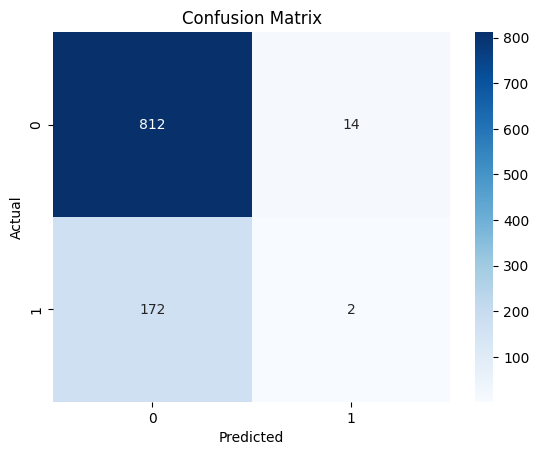

In [21]:
# ---------------------------
# Optional Step: Visualize the confusion matrix using a heatmap
# ---------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the confusion matrix as a heatmap for visual interpretation
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Code Breakdown:
Step 9 - Predictions:

The model (which already preprocesses data internally) predicts the target values on X_test.

We store the predictions in y_pred.

Step 10 - Model Evaluation:

We import the necessary metrics from sklearn.metrics.

The classification report provides key metrics (precision, recall, f1-score) for each class and is stored in report.

The confusion matrix shows how many predictions were made correctly or incorrectly for each class; it is stored in conf_matrix.

Step 11 - Display Results:

We print the classification report and the confusion matrix.

Optionally, a heatmap using Seaborn is created for a visual evaluation of the model’s performance.

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       826
           1       0.12      0.01      0.02       174

    accuracy                           0.81      1000
   macro avg       0.48      0.50      0.46      1000
weighted avg       0.70      0.81      0.74      1000


✅ Confusion Matrix:
[[812  14]
 [172   2]]


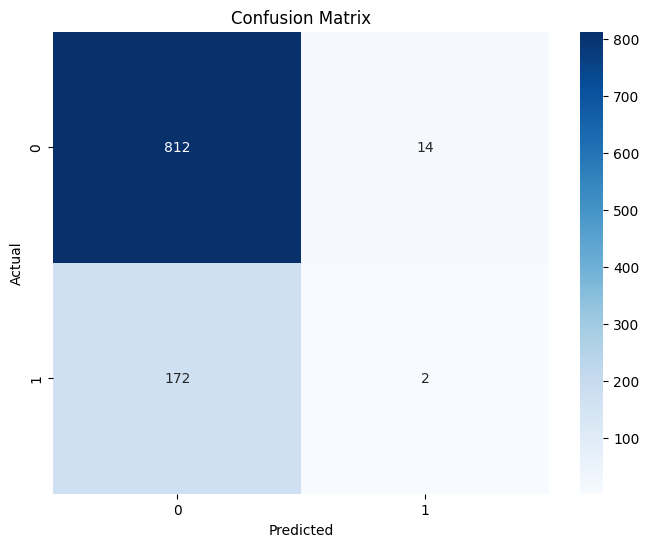

In [27]:
import os
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# Step 9: Make predictions using the trained model
# ---------------------------
y_pred = model.predict(X_test)

# ---------------------------
# Step 10: Evaluate the model's performance
# ---------------------------
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# ---------------------------
# Step 11: Print out the evaluation results
# ---------------------------
print("✅ Classification Report:")
print(report)

print("\n✅ Confusion Matrix:")
print(conf_matrix)

# ---------------------------
# Save the results to the output folder
# ---------------------------

# Ensure the output folder exists. In Kaggle, saving to a folder within the working directory is sufficient.
os.makedirs("output", exist_ok=True)

# Save classification report as a JSON file
with open("output/classification_report.json", "w") as f:
    json.dump(report, f, indent=4)

# Save confusion matrix as a CSV file
np.savetxt("output/confusion_matrix.csv", conf_matrix, delimiter=",", fmt='%d')

# ---------------------------
# Optional Step: Visualize and save the confusion matrix as a heatmap
# ---------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
# Save the heatmap to a file
plt.savefig("output/confusion_matrix_heatmap.png", dpi=300)
plt.show()

In [28]:
import pickle

# Save the trained model pipeline to a file using pickle
with open("output/model_pipeline.pkl", "wb") as f:
    pickle.dump(model, f)